In [1]:
# =============================================================================
# 1. IMPORTS AND SETUP
# =============================================================================
%load_ext autoreload
%autoreload 2
import os
import sys
import pathlib
import re
import gc
import yaml
import warnings
import time
from multiprocessing import Pool, cpu_count

# Suppress warnings
warnings.filterwarnings("ignore")

# --- Environment and JAX Configuration ---
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import jax
from jax.lib import xla_bridge
import jax.numpy as jnp
import jax_cosmo.background as bkgrd

# platform = xla_bridge.get_backend().platform
try:
    platform = xla_bridge.get_backend().platform
except:
    from jax.extend import backend
    platform = backend.get_backend().platform
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
print(f"JAX backend: {platform}, Total devices: {jax.device_count()}, Local devices: {jax.local_device_count()}")

import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()

# --- Library Imports ---
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import asdf
import healpy as hp
from tqdm import tqdm
import pickle as pk
import h5py as h5

# --- Matplotlib Configuration ---
plt.rcParams['text.usetex'] = True

# --- Add Project-Specific Paths ---
curr_path = pathlib.Path().absolute()
project_base = curr_path.parents[1] 
abs_path_data = project_base / "data"
abs_path_src = project_base / "src"
abs_path_results = project_base / "results"
abs_path_params = project_base / "param_files"

for path in [curr_path, abs_path_data, abs_path_src, abs_path_results, abs_path_params]:
    sys.path.append(str(path))

# --- Import Custom Modules ---
from godmax.get_radial_profiles import Profiles
from godmax.get_sim_maps import setup_sim_map, get_sim_map
import helpers.constants as constants




JAX backend: gpu, Total devices: 1, Local devices: 1


In [2]:
# =============================================================================
# 2. HELPER FUNCTIONS
# =============================================================================
def split_array_power_ratio(arr, num_parts, power_val=0.5):
    """Splits an array into parts with sizes proportional to j^power_val."""
    n_total = arr.shape[0]
    j_values = np.arange(1, num_parts + 1)
    weights = j_values**power_val
    sum_of_weights = np.sum(weights)
    ideal_sizes = (n_total / sum_of_weights) * weights
    
    int_sizes = np.floor(ideal_sizes).astype(int)
    remainder = n_total - np.sum(int_sizes)
    
    # Distribute remainder based on fractional parts
    fractional_parts = ideal_sizes - int_sizes
    indices_to_increment = np.argsort(fractional_parts)[-remainder:]
    int_sizes[indices_to_increment] += 1
    
    split_indices = np.cumsum(int_sizes)[:-1]
    return np.split(arr, split_indices)

def read_yaml(file_path):
    """Reads a YAML file and returns its content."""
    with open(file_path, 'r') as file:
        return yaml.safe_load(file)

def generate_dicts(data):
    """Extracts parameter dictionaries from the main data dictionary."""
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

# --- Functions for Parallel Halo Processing ---

def open_data(file, Mmin=1e13, Mmax=1e16):
    df = h5.File(ldir+file, 'r')
    M200c = df['M200c'][()]
    X, Y, Z = df['X'][()], df['Y'][()], df['Z'][()]
    VX, VY, VZ = df['VX'][()], df['VY'][()], df['VZ'][()]
    if (M200c.shape) is not None:
        indsel = np.where((M200c>Mmin) & (M200c<Mmax))[0]
        X_val = X[indsel]
        Y_val = Y[indsel]
        Z_val = Z[indsel]
        M200c_val = M200c[indsel]
        VX_val = VX[indsel]
        VY_val = VY[indsel]
        VZ_val = VZ[indsel]
        Vlos = (VX_val*X_val + VY_val*Y_val + VZ_val*Z_val)/np.sqrt(X_val**2 + Y_val**2 + Z_val**2)
    else:
        X_val = np.array([])
        Y_val = np.array([])
        Z_val = np.array([])
        M200c_val = np.array([])
        VX_val = np.array([])
        VY_val = np.array([])
        VZ_val = np.array([])
        Vlos = np.array([])
    df.close()
    return (X_val, Y_val, Z_val, Vlos, M200c_val)

def concatenate_data(results):
    # Pre-compute lengths for each part
    lengths = np.array([len(result[0]) for result in results])
    total_length = lengths.sum()

    # Pre-allocate arrays
    X_all = np.empty(total_length)
    Y_all = np.empty(total_length)
    Z_all = np.empty(total_length)
    Vlos_all = np.empty(total_length)
    M200_all = np.empty(total_length)

    # Calculate start and end indices
    end_ind_all = np.cumsum(lengths)
    start_ind_all = np.roll(end_ind_all, 1)
    start_ind_all[0] = 0


    # Use array slicing for assignment
    for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
        X_all[start:end] = result[0]
        Y_all[start:end] = result[1]
        Z_all[start:end] = result[2]
        Vlos_all[start:end] = result[3]
        M200_all[start:end] = result[4]

    return X_all, Y_all, Z_all, Vlos_all, M200_all

def process_halo(args):
    """Finds pixels near a single halo."""
    jhalo, ra_all_np, dec_all_np, halo_cat_R200c_np, halo_cat_DV_np, max_paint_R200c_factor, nside_local, pixel_dtype = args
    
    vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)
    # Angle subtended by the painting radius
    nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
    nearby_pix = hp.query_disc(nside_local, vec, nearby_angle)
    
    if len(nearby_pix) == 0:
        return None
    
    nearby_pix = np.asarray(nearby_pix, dtype=pixel_dtype)
    nearby_ra, nearby_dec = hp.pix2ang(nside_local, nearby_pix, lonlat=True)
    
    # Haversine formula to calculate angular separation
    ra1, dec1 = np.radians(ra_all_np[jhalo]), np.radians(dec_all_np[jhalo])
    ra2, dec2 = np.radians(nearby_ra), np.radians(nearby_dec)
    
    a = np.sin((dec1 - dec2)/2)**2 + np.cos(dec1) * np.cos(dec2) * np.sin((ra1 - ra2)/2)**2
    theta = np.clip(2 * np.arcsin(np.sqrt(a)), 1e-10, np.pi)  # Angular separation in radians
    
    # Projected distance in Mpc
    distances = (halo_cat_DV_np[jhalo] * theta).astype(np.float32)
    
    return (nearby_pix, distances, jhalo, len(nearby_pix))

def concatenate_batch_results(results, M_all_chunk, z_all_chunk, vlos_all_chunk, halo_cat_DV_np, halo_cat_R200c_np, max_paint_R200c_factor, pixel_dtype):
    """Concatenates results from a single batch of parallel processing."""
    if not results:
        return None
        
    lengths = np.array([res[3] for res in results], dtype=np.int32)
    total_length = lengths.sum()
    
    # Pre-allocate arrays for efficiency
    nearby_pix_all = np.empty(total_length, dtype=pixel_dtype)
    distances_pix_all = np.empty(total_length, dtype=np.float32)
    halo_indices = np.empty(total_length, dtype=np.int32)
    
    end_indices = np.cumsum(lengths)
    start_indices = np.concatenate([[0], end_indices[:-1]])
    
    for i, (start, end, res) in enumerate(zip(start_indices, end_indices, results)):
        nearby_pix_all[start:end] = res[0]
        distances_pix_all[start:end] = res[1]
        halo_indices[start:end] = res[2]
    
    original_halo_indices = np.array([res[2] for res in results], dtype=np.int32)
    
    # Map pixel-level properties back from halo-level properties
    logM_ind_all = np.log(M_all_chunk[halo_indices]).astype(np.float32)
    z_ind_all = z_all_chunk[halo_indices].astype(np.float32)
    vlos_ind_all = vlos_all_chunk[halo_indices].astype(np.float32)
    
    # Map halo-level properties
    ang_distance_all = halo_cat_DV_np[original_halo_indices].astype(np.float32)
    rp_max_all = (max_paint_R200c_factor * halo_cat_R200c_np[original_halo_indices]).astype(np.float32)
    
    return (nearby_pix_all, distances_pix_all, start_indices, end_indices, 
            logM_ind_all, z_ind_all, vlos_ind_all, ang_distance_all, rp_max_all)

def final_concatenate_batches(all_results, pixel_dtype):
    """Final concatenation of results from all batches."""
    total_pix = sum(len(res[0]) for res in all_results)
    total_halos = sum(len(res[2]) for res in all_results)
    
    # Pre-allocate final arrays
    final_nearby_pix = np.empty(total_pix, dtype=pixel_dtype)
    final_distances = np.empty(total_pix, dtype=np.float32)
    final_logM = np.empty(total_pix, dtype=np.float32)
    final_z = np.empty(total_pix, dtype=np.float32)
    final_vlos = np.empty(total_pix, dtype=np.float32)
    final_start_ind = np.empty(total_halos, dtype=np.int32)
    final_end_ind = np.empty(total_halos, dtype=np.int32)
    final_ang_dist = np.empty(total_halos, dtype=np.float32)
    final_rp_max = np.empty(total_halos, dtype=np.float32)
    
    pix_offset, halo_offset = 0, 0
    for result in all_results:
        n_pix_batch = len(result[0])
        n_halo_batch = len(result[2])
        
        # Unpack batch results
        nearby_pix_b, dist_b, start_b, end_b, logM_b, z_b, vlos_b, ang_dist_b, rp_max_b = result
        
        # Fill pixel-level arrays
        final_nearby_pix[pix_offset : pix_offset + n_pix_batch] = nearby_pix_b
        final_distances[pix_offset : pix_offset + n_pix_batch] = dist_b
        final_logM[pix_offset : pix_offset + n_pix_batch] = logM_b
        final_z[pix_offset : pix_offset + n_pix_batch] = z_b
        final_vlos[pix_offset : pix_offset + n_pix_batch] = vlos_b
        
        # Fill halo-level arrays, adjusting indices with the offset
        final_start_ind[halo_offset : halo_offset + n_halo_batch] = start_b + pix_offset
        final_end_ind[halo_offset : halo_offset + n_halo_batch] = end_b + pix_offset
        final_ang_dist[halo_offset : halo_offset + n_halo_batch] = ang_dist_b
        final_rp_max[halo_offset : halo_offset + n_halo_batch] = rp_max_b
        
        pix_offset += n_pix_batch
        halo_offset += n_halo_batch
        
    return (final_nearby_pix, final_distances, final_start_ind, final_end_ind,
            final_logM, final_z, final_vlos, final_ang_dist, final_rp_max)

def process_halos_in_batches(M_all_chunk, ra_all_chunk, dec_all_chunk, z_all_chunk, vlos_all_chunk, 
                             halo_cat_R200c, halo_cat_DA, max_paint_R200c_factor, nside, batch_size=1000):
    """Manages the parallel processing of halos in manageable batches."""
    pixel_dtype = np.int32 if nside <= 8192 else np.int64
    
    ra_all_np = np.clip(np.array(ra_all_chunk, dtype=np.float32), 0.01, 359.99)
    dec_all_np = np.clip(np.array(dec_all_chunk, dtype=np.float32), -89.99, 89.99)
    halo_cat_R200c_np = np.array(halo_cat_R200c, dtype=np.float32)
    halo_cat_DV_np = np.array(halo_cat_DA, dtype=np.float32)
    
    n_halos = len(z_all_chunk)
    all_results = []
    
    with Pool(cpu_count()) as pool:
        for batch_start in range(0, n_halos, batch_size):
            batch_end = min(batch_start + batch_size, n_halos)
            print(f"Processing halo batch {batch_start//batch_size + 1}/{(n_halos - 1)//batch_size + 1}...")
            
            # Create arguments for each halo in the batch
            batch_args = [(jhalo, ra_all_np, dec_all_np, halo_cat_R200c_np, halo_cat_DV_np, 
                           max_paint_R200c_factor, nside, pixel_dtype) for jhalo in range(batch_start, batch_end)]
            
            # Map processing to the pool
            batch_results = pool.map(process_halo, batch_args)
            batch_results = [r for r in batch_results if r is not None]
            
            if batch_results:
                # Concatenate results from the current batch
                batch_data = concatenate_batch_results(batch_results, M_all_chunk, z_all_chunk, vlos_all_chunk, 
                                                       halo_cat_DV_np, halo_cat_R200c_np, max_paint_R200c_factor, pixel_dtype)
                if batch_data is not None:
                    all_results.append(batch_data)
            
            del batch_results, batch_args
            gc.collect()
    
    if not all_results:
        return None
        
    return final_concatenate_batches(all_results, pixel_dtype)




In [3]:

# map_unbound_ds_smooth = hp.smoothing(map_unbound_ds, sigma=mock_map.sigma_val)
# map_bound_ds_smooth = hp.smoothing(map_bound_ds, sigma=mock_map.sigma_val)



In [7]:
# --- Timing Flag ---
PROFILE_TIMING = True
# PROFILE_TIMING = False

if PROFILE_TIMING:
    script_start_time = time.perf_counter()
    
# --- Analysis Parameters ---
# nside = 1024
nside = 512
jdevice = 0
Ndevices = 1
# theta_ej_val_all = [1.5, 2.0, 3.0, 4.0]
# nu_theta_ej_M_all = [-1.0, -0.5, -0.25, 0.0]
# nu_theta_ej_M_all = [-0.3, -0.2, -0.1, 0.0]
# nu_theta_ej_M_all = [-0.025, -0.05, -0.15]

# delta_fshmr_all = [0.0001, 0.1, 0.5, 0.8]
# delta_fshmr_all = [0.15, 0.2, 0.25, 0.3]
delta_fshmr_all = [0.35, 0.4]

Prof_test_all = {}
# from tqdm import tqdm
# for jth, nu_theta_ej_M in enumerate(nu_theta_ej_M_all):
for jth, deltav in enumerate(delta_fshmr_all):
    # --- Load Configuration and Initialize Models ---
    if PROFILE_TIMING:
        setup_start_time = time.perf_counter()

    yaml_file_path = f'{str(abs_path_params)}/params_default.yaml'
    data = read_yaml(yaml_file_path)
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(data)

    # Override halo parameters for this analysis
    halo_params_dict.update({
        'rmin': 0.00075, 'rmax': 10.0, 'nr': 32,
        'zmin': 0.005, 'zmax': 2.0, 'nz':31,
        # 'lg10_Mmin': 10.75, 'lg10_Mmax': 16.0, 'nM': 47
        'lg10_Mmin': 12.75, 'lg10_Mmax': 15.3, 'nM': 27
    })


    # sim_params_dict.update({'nu_theta_ej_M': nu_theta_ej_M})

    sim_params_dict.update({'delta_fshmr': deltav})
    sim_params_dict.update({'log10_Mstar0_theta_ej': 15.0})

    # cosmology of the backlight simulations
    cosmo_params_dict = {'w0': -1.0, 'flat': True, 'H0': 67.11, 'Om0': 0.3175, 
                            'Ob0': 0.049, 'sigma8': 0.834, 'ns': 0.9624}

    # Get the radial profiles
    Prof_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    # Prof_test_all[nu_theta_ej_M] = Prof_test
    Prof_test_all[deltav] = Prof_test

    # Setup simulated map generation. This also pre-computes some necessary 2D projection of the profiles needed for pasting
    mock_params_dict_setup = {}
    mock_params_dict_setup['nside'] = nside
    mock_params_dict_setup['get_ymap'] = True
    mock_params_dict_setup['get_kSZmap'] = True
    mock_params_dict_setup['get_taumap'] = True
    mock_params_dict_setup['get_kappamap'] = True
    mock_params_dict_setup['get_baryonifiedmap'] = True
    mock_params_dict_setup['get_galmap'] = True
    mock_params_dict_setup['smooth_profiles'] = True
    Paste_test = setup_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict_setup, Profiles_obj=Prof_test)

    chi2z_interp = interpolate.interp1d(np.log(Prof_test.chi_array), Prof_test.z_array, fill_value="extrapolate")

    if PROFILE_TIMING:
        setup_end_time = time.perf_counter()
        print(f"\n[PROFILE] Initial setup time: {setup_end_time - setup_start_time:.2f} seconds")

    # --- Identify Redshift Slices to Process ---
    sim_file_path = '/work/hdd/bdne/spandey3/backlight/fiducial/100'
    data_dir = f'{sim_file_path}/halos'
    files = [f for f in os.listdir(data_dir)]
    zlist = np.array(sorted(np.array([int(item) for item in files], dtype=int)))

    z2chi_file = f'{sim_file_path}/z2chi_interp.txt'
    z2chi = np.loadtxt(z2chi_file)

    zlist_file = f'{sim_file_path}/zlist.txt'
    zlist = np.loadtxt(zlist_file)
    snap_num_all = zlist[:,0].astype(int)
    zval_all = zlist[:,1]

    indz_all = np.where((zval_all < 0.1) & (zval_all > 0.05))[0]
    for indz in indz_all:
        zcen = zval_all[indz]
        # min_z = zcen + (zval_all[indz] - zval_all[indz-1])/2
        # max_z = zcen - (zval_all[indz+1] - zval_all[indz])/2

        snap_num = snap_num_all[indz]
        ldir = f'{sim_file_path}/halos/{snap_num}/'
        files_all = os.listdir(ldir)
        with Pool(cpu_count()) as pool:
            results = pool.map(open_data, files_all)
        X_all, Y_all, Z_all, vlos_all, M200c_all = concatenate_data(results)
        ra_all, dec_all = hp.vec2ang(np.array([X_all, Y_all, Z_all]).T, lonlat=True)
        z_all = zcen * np.ones_like(ra_all)
        ra_all, dec_all = np.clip(ra_all, 0, 360), np.clip(dec_all, -90, 90)

        print(zcen, len(ra_all), np.min(np.log10(M200c_all)), np.max(np.log10(M200c_all)))

        if jth == 0:
            rho_m = Prof_test.get_rho_m(0.0)
            Mtot = rho_m * (1000)**3
            part_mass = float(Mtot/2048**3)

            # map_unbound = hp.read_map(f'{sim_file_path}/compressed_massMaps/massSheet_unbound_z_{int(snap_num)}.fits.gz')
            # map_unbound_ds = hp.ud_grade(np.array(map_unbound*part_mass), nside, power=-2)

            map_tot_orig = hp.read_map(f'{sim_file_path}/compressed_massMaps/massSheet_tot_z_{int(snap_num)}.fits.gz')
            map_tot_orig_ds = hp.ud_grade(np.array(map_tot_orig*part_mass), nside, power=-2)

            # map_bound = map_tot_orig - map_unbound
            # map_bound_ds = hp.ud_grade(np.array(map_bound*part_mass), nside, power=-2)


        # --- Chunking and Map Generation ---
        nh_max_map = {8192: 4e3, 4096: 5e4, 2048: 5e5, 1024: 1e7, 512: 1e7}
        nh_max = nh_max_map.get(nside, 1e5) # Default if nside not in map
        nsel = len(M200c_all)
        num_chunks = int(np.ceil(nsel / nh_max)) if nsel > nh_max else 1

        map_rhom_dmb, map_rhom_dmo, map_kappa, map_ymap, map_ksz, map_tau = (np.zeros(12 * nside**2, dtype=np.float32) for _ in range(6))
        mock_gals_all = {}

        for i in tqdm(range(num_chunks), desc=f"Painting maps for z={zcen:.3f}"):
            start, end = int(i * nh_max), int((i + 1) * nh_max)
            M_chunk, ra_chunk, dec_chunk, z_chunk, vlos_chunk = (
                M200c_all[start:end], ra_all[start:end], dec_all[start:end],
                z_all[start:end], vlos_all[start:end]
            )
            
            scale_fac = 1. / (1. + z_chunk)
            rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(Prof_test.cosmo_jax, scale_fac) * 1e9
            rho_treshold = 200 * rho_c_z
            R200c = (M_chunk * 3.0 / (4.0 * jnp.pi * rho_treshold))**(1.0 / 3.0)
            DA = bkgrd.angular_diameter_distance(Prof_test.cosmo_jax, scale_fac)
            
            if PROFILE_TIMING:
                pixel_finding_start_time = time.perf_counter()
            
            max_paint_R200c_factor = 3.0
            batch_size = int(nh_max // 2) if nh_max > 2 else 1
            result = process_halos_in_batches(
                M_chunk, ra_chunk, dec_chunk, z_chunk, vlos_chunk,
                R200c, DA, max_paint_R200c_factor, nside, batch_size
            )
            
            if PROFILE_TIMING:
                pixel_finding_end_time = time.perf_counter()
                print(f"\n[PROFILE] Chunk {i+1}/{num_chunks} - Pixel finding: {pixel_finding_end_time - pixel_finding_start_time:.2f} seconds")
            
            if result:
                mock_params_dict = {
                    **mock_params_dict_setup,
                    'halo_z': jnp.array(z_chunk, dtype=jnp.float32),
                    'halo_ra': jnp.array(ra_chunk, dtype=jnp.float32),
                    'halo_dec': jnp.array(dec_chunk, dtype=jnp.float32),
                    'halo_M': jnp.array(M_chunk, dtype=jnp.float32),
                    'halo_vlos': jnp.array(vlos_chunk, dtype=jnp.float32),
                    'nearby_pix_all': jnp.array(result[0]),
                    'start_ind': jnp.array(result[2], dtype=jnp.int32),
                    'end_ind': jnp.array(result[3], dtype=jnp.int32),
                    'pix_prop_all': (jnp.array([np.log(result[1]), result[5], result[4], result[6]]).T).astype(jnp.float32),
                    'ang_distance_all': jnp.array(result[7]),
                    'rp_max_all': jnp.array(result[8]),
                    'profile_timing': PROFILE_TIMING
                }
                
                if PROFILE_TIMING:
                    map_gen_start_time = time.perf_counter()
                
                mock_map = get_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict, Profiles_obj=Paste_test)
                
                map_rhom_dmb += np.nan_to_num(mock_map.rhommap_final)
                map_rhom_dmo += np.nan_to_num(mock_map.rhom_dmo_map_final)
                map_ymap += np.nan_to_num(mock_map.ymap_final)
                map_ksz += np.nan_to_num(mock_map.kszmap_final)
                map_tau += np.nan_to_num(mock_map.taumap_final)
                mock_gals_all[i] = mock_map.final_galaxy_catalog

                map_tot_orig_ds_smooth = hp.smoothing(map_tot_orig_ds, sigma=mock_map.sigma_val)

                map_diff = map_rhom_dmb - map_rhom_dmo
                map_kappa += map_tot_orig_ds_smooth + map_diff

                if PROFILE_TIMING:
                    map_gen_end_time = time.perf_counter()
                    print(f"[PROFILE] Chunk {i+1}/{num_chunks} - JAX map generation: {map_gen_end_time - map_gen_start_time:.2f} seconds")
                
                # del mock_map, mock_params_dict, result
                # jax.clear_caches()
                # gc.collect()


            saved_data = {'mock_gals_all': mock_gals_all, 'map_rhom_dmb': map_rhom_dmb, 
                            'map_ymap': map_ymap, 'map_ksz': map_ksz, 'map_tau': map_tau,
                            'map_kappa': map_kappa, 'map_rhom_dmo': map_rhom_dmo}
            

            sdir = '/projects/bdne/spandey3/temp/'
            os.makedirs(sdir, exist_ok=True)
            # save_map_fname = f'{sdir}/allmaps_sim_B12_nside{nside}_z{zcen:.3f}_nu_theta{nu_theta_ej_M}.pkl'
            save_map_fname = f'{sdir}/allmaps_sim_B12_nside{nside}_z{zcen:.3f}_delta{deltav}.pkl'

            with open(save_map_fname, 'wb') as f:
                pk.dump(saved_data, f)







[PROFILE] Initial setup time: 58.27 seconds
0.0911345 11103 13.000086872398617 15.126877886529002


Painting maps for z=0.091:   0%|          | 0/1 [00:00<?, ?it/s]

Processing halo batch 1/1...

[PROFILE] Chunk 1/1 - Pixel finding: 6.97 seconds

--- JAX Map Generation Timing Profile ---
setup_common                       : 0.1602 seconds
setup_tau_interpolator             : 0.3174 seconds
ymap_generation_and_assembly       : 1.0679 seconds
ksz_map_generation_and_assembly    : 1.4250 seconds
tau_map_generation_and_assembly    : 0.9983 seconds
kappa_map_generation_and_assembly  : 1.1066 seconds
kappa_dmo_map_generation_and_assembly: 1.1891 seconds
galaxy_ppf_interpolator_creation   : 0.1358 seconds
galaxy_population                  : 2.6453 seconds
galaxy_catalog_filtering           : 0.3426 seconds
total_execution                    : 9.4024 seconds
---------------------------------------



Painting maps for z=0.091: 100%|██████████| 1/1 [00:17<00:00, 17.07s/it]

[PROFILE] Chunk 1/1 - JAX map generation: 9.84 seconds


...

0.05939679 4739 13.000086872398617 15.050920846101869


Painting maps for z=0.059:   0%|          | 0/1 [00:00<?, ?it/s]

Processing halo batch 1/1...

[PROFILE] Chunk 1/1 - Pixel finding: 7.13 seconds

--- JAX Map Generation Timing Profile ---
setup_common                       : 0.1334 seconds
setup_tau_interpolator             : 0.3370 seconds
ymap_generation_and_assembly       : 1.3195 seconds
ksz_map_generation_and_assembly    : 1.3147 seconds
tau_map_generation_and_assembly    : 1.0915 seconds
kappa_map_generation_and_assembly  : 1.1579 seconds
kappa_dmo_map_generation_and_assembly: 1.1712 seconds
galaxy_ppf_interpolator_creation   : 0.1393 seconds
galaxy_population                  : 3.3620 seconds
galaxy_catalog_filtering           : 0.0033 seconds
total_execution                    : 10.0471 seconds
---------------------------------------



Painting maps for z=0.059: 100%|██████████| 1/1 [00:17<00:00, 17.95s/it]

[PROFILE] Chunk 1/1 - JAX map generation: 10.60 seconds


In [6]:
nside = 512
sim_file_path = '/work/hdd/bdne/spandey3/backlight/fiducial/100'
data_dir = f'{sim_file_path}/halos'
files = [f for f in os.listdir(data_dir)]
zlist = np.array(sorted(np.array([int(item) for item in files], dtype=int)))

z2chi_file = f'{sim_file_path}/z2chi_interp.txt'
z2chi = np.loadtxt(z2chi_file)

zlist_file = f'{sim_file_path}/zlist.txt'
zlist = np.loadtxt(zlist_file)
snap_num_all = zlist[:,0].astype(int)
zval_all = zlist[:,1]

indz_all = np.where((zval_all < 0.1) & (zval_all > 0.05))[0]


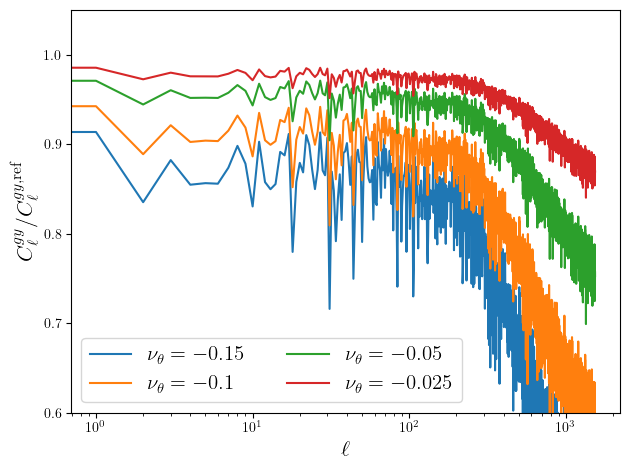

In [13]:
ymap_data = {}
gmap_data = {}
cl_yy = {}
cl_gy = {}
lmax = 3 * nside - 1

nu_theta_ej_M_all = [-0.15, -0.1,  -0.05,  -0.025, 0.0]
# nu_theta_ej_M_all = [-0.025, -0.05, -0.15]

for jth, nu_theta_ej_M in enumerate(nu_theta_ej_M_all):
    map_ymap_all = np.zeros(12*nside**2)
    map_gal_all = np.zeros(12*nside**2)
    for indz in indz_all:              
        sdir = '/projects/bdne/spandey3/temp/'
        zcen = zval_all[indz]
        save_map_fname = f'{sdir}/allmaps_sim_B12_nside{nside}_z{zcen:.3f}_nu_theta{nu_theta_ej_M}.pkl'
        with open(save_map_fname, 'rb') as f:
            data = pk.load(f)
        map_ymap_all  += data['map_ymap']
        mock_gals_all = data['mock_gals_all']
        gal_ra_all, gal_dec_all = mock_gals_all[0][:,0], mock_gals_all[0][:,1]
        gal_pix_all = hp.ang2pix(nside, gal_ra_all, gal_dec_all, lonlat=True)
        map_gal_all += np.bincount(gal_pix_all, minlength=12*nside**2)
    ymap_data[nu_theta_ej_M] = map_ymap_all
    gmap_data[nu_theta_ej_M] = map_gal_all
    cl_yy[nu_theta_ej_M] = hp.anafast(ymap_data[nu_theta_ej_M], 
                                   ymap_data[nu_theta_ej_M], lmax=lmax)

    cl_gy[nu_theta_ej_M] = hp.anafast(gmap_data[nu_theta_ej_M], 
                                   ymap_data[nu_theta_ej_M], lmax=lmax)


# Reference case
cl_ref = cl_gy[0.0]

ell = np.arange(len(cl_ref))

# Plot ratios
plt.figure()
for nu_theta in nu_theta_ej_M_all[:-1]:  # Exclude reference case
    plt.plot(ell, cl_gy[nu_theta] / cl_ref, 
             label=rf'$\nu_\theta = {nu_theta}$')

plt.legend(ncol=2, fontsize=15, loc='lower left')
plt.xscale('log')
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$C_\ell^{gy} / C_\ell^{gy,\mathrm{ref}}$', fontsize=16)
plt.ylim(0.6, 1.05)
plt.tight_layout()
plt.show()






In [11]:
mock_gals_all[0][:,0]

Array([ 26.11922 ,  26.172934,  10.518317, ..., 244.75043 , 229.67989 ,
       264.2312  ], dtype=float32)

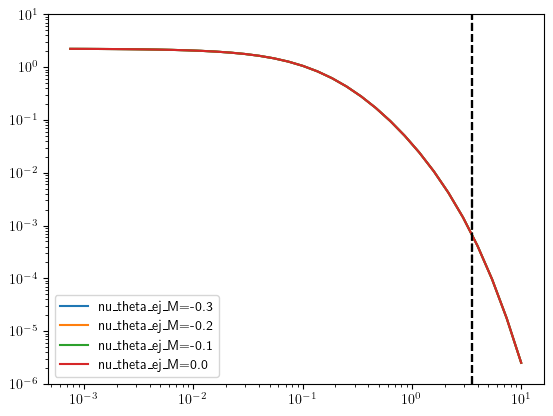

In [7]:
plt.figure()
for jth, nu_theta_ej_M in enumerate(nu_theta_ej_M_all):
    Prof_test = Prof_test_all[nu_theta_ej_M]
    plt.loglog(Prof_test.r_array, Prof_test.Pe_mat_physical[:,0,45], label=f'nu_theta_ej_M={nu_theta_ej_M}')
    plt.axvline(Prof_test.r200c_mat[0,40], color='k', linestyle='--')
    # plt.ylim(1e-10, 1e-5)
    plt.ylim(1e-6, 1e1)

plt.legend()




In [5]:
import pickle as pk
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

sdir = '/projects/bdne/spandey3/temp/'
nu_theta_values = [-0.3, -0.2, -0.1, 0.0]
lmax = 3 * nside - 1

# Store results
smoothed_galaxy_maps = {}
ymap_data = {}
cl_gy = {}

# Process each nu_theta value
for nu_theta in nu_theta_values:
    fname = f'{sdir}/allmaps_sim_B12_nside{nside}_nu_theta{nu_theta}.pkl'
    
    with open(fname, 'rb') as f:
        data = pk.load(f)

    ymap_data[nu_theta] = data['map_ymap']
    print(np.mean(ymap_data[nu_theta]), np.std(ymap_data[nu_theta] ))
    



3.5534145e-09 6.959961e-08
5.5222125e-09 9.46093e-08
8.126617e-09 1.2777757e-07
1.0972907e-08 1.7004372e-07


In [14]:
for jth, nu_theta_ej_M in enumerate(nu_theta_ej_M_all):
    Prof_test = Prof_test_all[nu_theta_ej_M]
    print(Prof_test.Pe_mat_physical[0,0,30])



2.0970377960938152e-05
5.740729668035988e-05
0.00039338262414639126
0.0036441684602895566


In [ ]:
nu_theta_ej_M_all.append(0.0)
nu_theta_ej_M_all


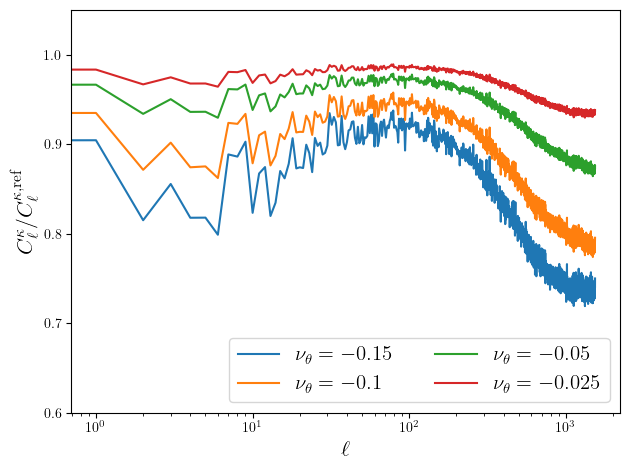

In [15]:
ymap_data = {}
cl_yy = {}
lmax = 3 * nside - 1

nu_theta_ej_M_all = [-0.15, -0.1,  -0.05,  -0.025, 0.0]
# nu_theta_ej_M_all = [-0.025, -0.05, -0.15]

for jth, nu_theta_ej_M in enumerate(nu_theta_ej_M_all):
    map_ymap_all = np.zeros(12*nside**2)
    for indz in indz_all:              
        sdir = '/projects/bdne/spandey3/temp/'
        zcen = zval_all[indz]
        save_map_fname = f'{sdir}/allmaps_sim_B12_nside{nside}_z{zcen:.3f}_nu_theta{nu_theta_ej_M}.pkl'
        with open(save_map_fname, 'rb') as f:
            data = pk.load(f)
        map_ymap_all  += data['map_ymap']
    ymap_data[nu_theta_ej_M] = map_ymap_all
    cl_yy[nu_theta_ej_M] = hp.anafast(ymap_data[nu_theta_ej_M], 
                                   ymap_data[nu_theta_ej_M], lmax=lmax)

# Reference case
cl_ref = cl_yy[0.0]
ell = np.arange(len(cl_ref))

# Plot ratios
plt.figure()
for nu_theta in nu_theta_ej_M_all[:-1]:  # Exclude reference case
    plt.plot(ell, cl_yy[nu_theta] / cl_ref, 
             label=rf'$\nu_\theta = {nu_theta}$')

plt.legend(ncol=2, fontsize=15, loc='lower right')
plt.xscale('log')
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$C_\ell^{\kappa} / C_\ell^{\kappa,\mathrm{ref}}$', fontsize=16)
plt.ylim(0.6, 1.05)
plt.tight_layout()
plt.show()




In [17]:
# cl_yy
nu_theta_ej_M_all

[-0.3, -0.2, -0.1, 0.0]

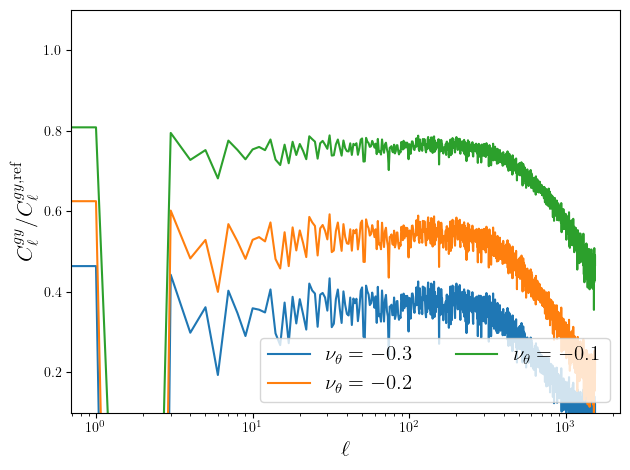

In [10]:
import pickle as pk
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

sdir = '/projects/bdne/spandey3/temp/'
nu_theta_values = [-0.3, -0.2, -0.1, 0.0]
lmax = 3 * nside - 1

# Store results
smoothed_galaxy_maps = {}
ymap_data = {}
cl_gy = {}

# Process each nu_theta value
for nu_theta in nu_theta_values:
    fname = f'{sdir}/allmaps_sim_B12_nside{nside}_nu_theta{nu_theta}.pkl'
    
    with open(fname, 'rb') as f:
        data = pk.load(f)
    
    # Extract galaxy positions
    gal_ra = data['mock_gals_all'][0][:, 0]
    gal_dec = data['mock_gals_all'][0][:, 1]
    
    # Create galaxy density map
    galaxy_map = np.zeros(12 * nside**2, dtype=np.float32)
    pixels = hp.ang2pix(nside, gal_ra, gal_dec, lonlat=True)
    np.add.at(galaxy_map, pixels, 1.)
    
    # Compute overdensity and smooth
    delta_gal = galaxy_map / np.mean(galaxy_map)
    smoothed_galaxy_maps[nu_theta] = hp.smoothing(delta_gal, sigma=mock_map.sigma_val)
    ymap_data[nu_theta] = data['map_ymap']
    
    # Compute cross-spectrum
    cl_gy[nu_theta] = hp.anafast(smoothed_galaxy_maps[nu_theta], 
                                   ymap_data[nu_theta], lmax=lmax)

# Reference case
cl_ref = cl_gy[0.0]
ell = np.arange(len(cl_ref))

# Plot ratios
plt.figure()
for nu_theta in nu_theta_values[:-1]:  # Exclude reference case
    plt.plot(ell, cl_gy[nu_theta] / cl_ref, 
             label=rf'$\nu_\theta = {nu_theta}$')

plt.legend(ncol=2, fontsize=15, loc='lower right')
plt.xscale('log')
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$C_\ell^{gy} / C_\ell^{gy,\mathrm{ref}}$', fontsize=16)
plt.ylim(0.1, 1.1)
plt.tight_layout()
plt.show()




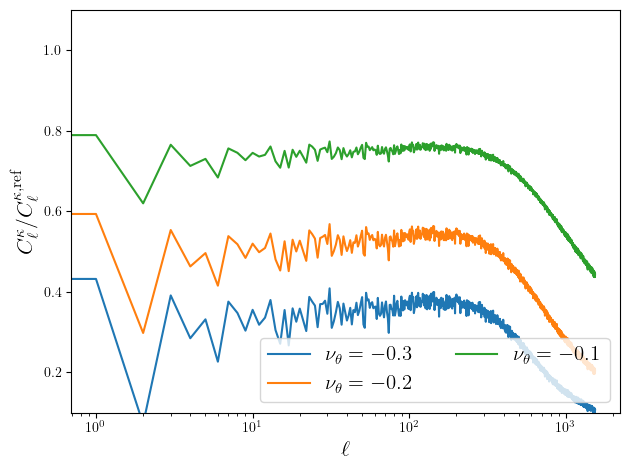

In [22]:
import pickle as pk
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

sdir = '/projects/bdne/spandey3/temp/'
nu_theta_values = [-0.3, -0.2, -0.1, 0.0]
lmax = 3 * nside - 1

# Store results
smoothed_galaxy_maps = {}
ymap_data = {}
kappa_data = {}
cl_kappa = {}

# Process each nu_theta value
for nu_theta in nu_theta_values:
    fname = f'{sdir}/allmaps_sim_B12_nside{nside}_nu_theta{nu_theta}.pkl'
    
    with open(fname, 'rb') as f:
        data = pk.load(f)

    ymap_data[nu_theta] = data['map_ymap']
    kappa_data[nu_theta] = data['map_kappa']
    
    # Compute cross-spectrum
    cl_kappa[nu_theta] = hp.anafast(kappa_data[nu_theta], 
                                   ymap_data[nu_theta], lmax=lmax)

# Reference case
cl_ref = cl_kappa[0.0]
ell = np.arange(len(cl_ref))

# Plot ratios
plt.figure()
for nu_theta in nu_theta_values[:-1]:  # Exclude reference case
    plt.plot(ell, cl_kappa[nu_theta] / cl_ref, 
             label=rf'$\nu_\theta = {nu_theta}$')

plt.legend(ncol=2, fontsize=15, loc='lower right')
plt.xscale('log')
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$C_\ell^{\kappa} / C_\ell^{\kappa,\mathrm{ref}}$', fontsize=16)
plt.ylim(0.1, 1.1)
plt.tight_layout()
plt.show()




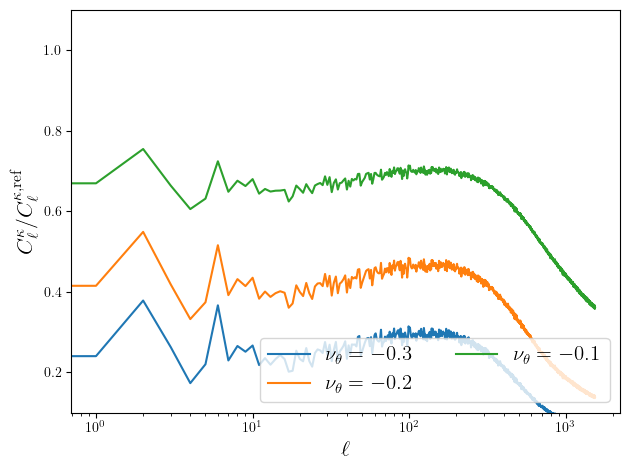

In [23]:
import pickle as pk
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

sdir = '/projects/bdne/spandey3/temp/'
nu_theta_values = [-0.3, -0.2, -0.1, 0.0]
lmax = 3 * nside - 1

# Store results
smoothed_galaxy_maps = {}
ymap_data = {}
kappa_data = {}
cl_yy = {}

# Process each nu_theta value
for nu_theta in nu_theta_values:
    fname = f'{sdir}/allmaps_sim_B12_nside{nside}_nu_theta{nu_theta}.pkl'
    
    with open(fname, 'rb') as f:
        data = pk.load(f)

    ymap_data[nu_theta] = data['map_ymap']
    kappa_data[nu_theta] = data['map_kappa']
    
    # Compute cross-spectrum
    cl_yy[nu_theta] = hp.anafast(ymap_data[nu_theta], 
                                   ymap_data[nu_theta], lmax=lmax)

# Reference case
cl_ref = cl_yy[0.0]
ell = np.arange(len(cl_ref))

# Plot ratios
plt.figure()
for nu_theta in nu_theta_values[:-1]:  # Exclude reference case
    plt.plot(ell, cl_yy[nu_theta] / cl_ref, 
             label=rf'$\nu_\theta = {nu_theta}$')

plt.legend(ncol=2, fontsize=15, loc='lower right')
plt.xscale('log')
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$C_\ell^{\kappa} / C_\ell^{\kappa,\mathrm{ref}}$', fontsize=16)
plt.ylim(0.1, 1.1)
plt.tight_layout()
plt.show()




In [3]:

def open_data(file, Mmin=1e15, Mmax=1e16):
    df = h5.File(ldir+file, 'r')
    M200c = df['M200c'][()]
    X, Y, Z = df['X'][()], df['Y'][()], df['Z'][()]
    VX, VY, VZ = df['VX'][()], df['VY'][()], df['VZ'][()]
    if (M200c.shape) is not None:
        indsel = np.where((M200c>Mmin) & (M200c<Mmax))[0]
        X_val = X[indsel]
        Y_val = Y[indsel]
        Z_val = Z[indsel]
        M200c_val = M200c[indsel]
        VX_val = VX[indsel]
        VY_val = VY[indsel]
        VZ_val = VZ[indsel]
        Vlos = (VX_val*X_val + VY_val*Y_val + VZ_val*Z_val)/np.sqrt(X_val**2 + Y_val**2 + Z_val**2)
    else:
        X_val = np.array([])
        Y_val = np.array([])
        Z_val = np.array([])
        M200c_val = np.array([])
        VX_val = np.array([])
        VY_val = np.array([])
        VZ_val = np.array([])
        Vlos = np.array([])
    df.close()
    return (X_val, Y_val, Z_val, Vlos, M200c_val)

# --- Timing Flag ---
PROFILE_TIMING = True
# PROFILE_TIMING = False

if PROFILE_TIMING:
    script_start_time = time.perf_counter()
    
# --- Analysis Parameters ---
# nside = 1024
nside = 512
jdevice = 0
Ndevices = 1
# theta_ej_val_all = [1.5, 2.0, 3.0, 4.0]
# nu_theta_ej_M_all = [-1.0, -0.5, -0.25, 0.0]
nu_theta_ej_M_all = [-0.3, -0.2, -0.1, 0.0]
Prof_test_all = {}
# from tqdm import tqdm
for jth, nu_theta_ej_M in enumerate(nu_theta_ej_M_all):

    # --- Load Configuration and Initialize Models ---
    if PROFILE_TIMING:
        setup_start_time = time.perf_counter()

    yaml_file_path = f'{str(abs_path_params)}/params_default.yaml'
    data = read_yaml(yaml_file_path)
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(data)

    # Override halo parameters for this analysis
    halo_params_dict.update({
        'rmin': 0.00075, 'rmax': 10.0, 'nr': 32,
        'zmin': 0.005, 'zmax': 2.0, 'nz':31,
        # 'lg10_Mmin': 10.75, 'lg10_Mmax': 16.0, 'nM': 47
        'lg10_Mmin': 12.75, 'lg10_Mmax': 15.2, 'nM': 27
    })


    # theta_ej_val = 3.0

    sim_params_dict.update({'nu_theta_ej_M': nu_theta_ej_M})
    sim_params_dict.update({'log10_Mstar0_theta_ej': 15.2})

    # cosmology of the backlight simulations
    cosmo_params_dict = {'w0': -1.0, 'flat': True, 'H0': 67.11, 'Om0': 0.3175, 
                            'Ob0': 0.049, 'sigma8': 0.834, 'ns': 0.9624}

    # Get the radial profiles
    Prof_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    Prof_test_all[nu_theta_ej_M] = Prof_test

    # Setup simulated map generation. This also pre-computes some necessary 2D projection of the profiles needed for pasting
    mock_params_dict_setup = {}
    mock_params_dict_setup['nside'] = nside
    mock_params_dict_setup['get_ymap'] = True
    mock_params_dict_setup['get_kSZmap'] = True
    mock_params_dict_setup['get_taumap'] = True
    mock_params_dict_setup['get_kappamap'] = True
    mock_params_dict_setup['get_baryonifiedmap'] = True
    mock_params_dict_setup['get_galmap'] = True
    mock_params_dict_setup['smooth_profiles'] = False
    Paste_test = setup_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict_setup, Profiles_obj=Prof_test)

    chi2z_interp = interpolate.interp1d(np.log(Prof_test.chi_array), Prof_test.z_array, fill_value="extrapolate")

    if PROFILE_TIMING:
        setup_end_time = time.perf_counter()
        print(f"\n[PROFILE] Initial setup time: {setup_end_time - setup_start_time:.2f} seconds")

    # --- Identify Redshift Slices to Process ---
    sim_file_path = '/work/hdd/bdne/spandey3/backlight/fiducial/100'
    data_dir = f'{sim_file_path}/halos'
    files = [f for f in os.listdir(data_dir)]
    zlist = np.array(sorted(np.array([int(item) for item in files], dtype=int)))

    z2chi_file = f'{sim_file_path}/z2chi_interp.txt'
    z2chi = np.loadtxt(z2chi_file)

    zlist_file = f'{sim_file_path}/zlist.txt'
    zlist = np.loadtxt(zlist_file)
    snap_num_all = zlist[:,0].astype(int)
    zval_all = zlist[:,1]

    indz_all = np.where((zval_all < 0.1) & (zval_all > 0.005))[0][0]
    # for indz in indz_all:    
    for indz in [indz_all]:
        zcen = zval_all[indz]
        # min_z = zcen + (zval_all[indz] - zval_all[indz-1])/2
        # max_z = zcen - (zval_all[indz+1] - zval_all[indz])/2

        snap_num = snap_num_all[indz]
        ldir = f'{sim_file_path}/halos/{snap_num}/'
        files_all = os.listdir(ldir)
        with Pool(cpu_count()) as pool:
            results = pool.map(open_data, files_all)
        X_all, Y_all, Z_all, vlos_all, M200c_all = concatenate_data(results)
        ra_all, dec_all = hp.vec2ang(np.array([X_all, Y_all, Z_all]).T, lonlat=True)
        z_all = zcen * np.ones_like(ra_all)
        ra_all, dec_all = np.clip(ra_all, 0, 360), np.clip(dec_all, -90, 90)

        print(zcen, len(ra_all), np.min(np.log10(M200c_all)), np.max(np.log10(M200c_all)))

        if jth == 0:
            rho_m = Prof_test.get_rho_m(0.0)
            Mtot = rho_m * (1000)**3
            part_mass = float(Mtot/2048**3)

            # map_unbound = hp.read_map(f'{sim_file_path}/compressed_massMaps/massSheet_unbound_z_{int(snap_num)}.fits.gz')
            # map_unbound_ds = hp.ud_grade(np.array(map_unbound*part_mass), nside, power=-2)

            map_tot_orig = hp.read_map(f'{sim_file_path}/compressed_massMaps/massSheet_tot_z_{int(snap_num)}.fits.gz')
            map_tot_orig_ds = hp.ud_grade(np.array(map_tot_orig*part_mass), nside, power=-2)

            # map_bound = map_tot_orig - map_unbound
            # map_bound_ds = hp.ud_grade(np.array(map_bound*part_mass), nside, power=-2)


        # --- Chunking and Map Generation ---
        nh_max_map = {8192: 4e3, 4096: 5e4, 2048: 5e5, 1024: 1e7, 512: 1e7}
        nh_max = nh_max_map.get(nside, 1e5) # Default if nside not in map
        nsel = len(M200c_all)
        num_chunks = int(np.ceil(nsel / nh_max)) if nsel > nh_max else 1

        map_rhom_dmb, map_rhom_dmo, map_kappa, map_ymap, map_ksz, map_tau = (np.zeros(12 * nside**2, dtype=np.float32) for _ in range(6))
        mock_gals_all = {}

        for i in tqdm(range(num_chunks), desc=f"Painting maps for z={zcen:.3f}"):
            start, end = int(i * nh_max), int((i + 1) * nh_max)
            M_chunk, ra_chunk, dec_chunk, z_chunk, vlos_chunk = (
                M200c_all[start:end], ra_all[start:end], dec_all[start:end],
                z_all[start:end], vlos_all[start:end]
            )
            
            scale_fac = 1. / (1. + z_chunk)
            rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(Prof_test.cosmo_jax, scale_fac) * 1e9
            rho_treshold = 200 * rho_c_z
            R200c = (M_chunk * 3.0 / (4.0 * jnp.pi * rho_treshold))**(1.0 / 3.0)
            DA = bkgrd.angular_diameter_distance(Prof_test.cosmo_jax, scale_fac)
            
            if PROFILE_TIMING:
                pixel_finding_start_time = time.perf_counter()
            
            max_paint_R200c_factor = 3.0
            batch_size = int(nh_max // 2) if nh_max > 2 else 1
            result = process_halos_in_batches(
                M_chunk, ra_chunk, dec_chunk, z_chunk, vlos_chunk,
                R200c, DA, max_paint_R200c_factor, nside, batch_size
            )
            
            if PROFILE_TIMING:
                pixel_finding_end_time = time.perf_counter()
                print(f"\n[PROFILE] Chunk {i+1}/{num_chunks} - Pixel finding: {pixel_finding_end_time - pixel_finding_start_time:.2f} seconds")
            
            if result:
                mock_params_dict = {
                    **mock_params_dict_setup,
                    'halo_z': jnp.array(z_chunk, dtype=jnp.float32),
                    'halo_ra': jnp.array(ra_chunk, dtype=jnp.float32),
                    'halo_dec': jnp.array(dec_chunk, dtype=jnp.float32),
                    'halo_M': jnp.array(M_chunk, dtype=jnp.float32),
                    'halo_vlos': jnp.array(vlos_chunk, dtype=jnp.float32),
                    'nearby_pix_all': jnp.array(result[0]),
                    'start_ind': jnp.array(result[2], dtype=jnp.int32),
                    'end_ind': jnp.array(result[3], dtype=jnp.int32),
                    'pix_prop_all': (jnp.array([np.log(result[1]), result[5], result[4], result[6]]).T).astype(jnp.float32),
                    'ang_distance_all': jnp.array(result[7]),
                    'rp_max_all': jnp.array(result[8]),
                    'profile_timing': PROFILE_TIMING
                }
                
                if PROFILE_TIMING:
                    map_gen_start_time = time.perf_counter()
                
                mock_map = get_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict, Profiles_obj=Paste_test)
                
                map_rhom_dmb += np.nan_to_num(mock_map.rhommap_final)
                map_rhom_dmo += np.nan_to_num(mock_map.rhom_dmo_map_final)
                map_ymap += np.nan_to_num(mock_map.ymap_final)
                map_ksz += np.nan_to_num(mock_map.kszmap_final)
                map_tau += np.nan_to_num(mock_map.taumap_final)
                mock_gals_all[i] = mock_map.final_galaxy_catalog

                map_tot_orig_ds_smooth = hp.smoothing(map_tot_orig_ds, sigma=mock_map.sigma_val)

                map_diff = map_rhom_dmb - map_rhom_dmo
                map_kappa += map_tot_orig_ds_smooth + map_diff

                if PROFILE_TIMING:
                    map_gen_end_time = time.perf_counter()
                    print(f"[PROFILE] Chunk {i+1}/{num_chunks} - JAX map generation: {map_gen_end_time - map_gen_start_time:.2f} seconds")
                
                # del mock_map, mock_params_dict, result
                # jax.clear_caches()
                # gc.collect()


            saved_data = {'mock_gals_all': mock_gals_all, 'map_rhom_dmb': map_rhom_dmb, 
                            'map_ymap': map_ymap, 'map_ksz': map_ksz, 'map_tau': map_tau,
                            'map_kappa': map_kappa, 'map_rhom_dmo': map_rhom_dmo}
            
            print(np.mean(map_ymap[map_ymap!=0]), np.std(map_ymap[map_ymap!=0]))
            sdir = '/projects/bdne/spandey3/temp/'
            os.makedirs(sdir, exist_ok=True)
            save_map_fname = f'{sdir}/allmaps_sim_B12_nside{nside}_z{zcen:.3f}_nu_theta{nu_theta_ej_M}_Mminhigh_nosmooth.pkl'

            with open(save_map_fname, 'wb') as f:
                pk.dump(saved_data, f)







[PROFILE] Initial setup time: 21.82 seconds
0.0911345 2 15.09457594039316 15.126877886529002


Painting maps for z=0.091:   0%|          | 0/1 [00:00<?, ?it/s]

Processing halo batch 1/1...

[PROFILE] Chunk 1/1 - Pixel finding: 3.86 seconds

--- JAX Map Generation Timing Profile ---
setup_common                       : 0.4100 seconds
setup_tau_interpolator             : 0.2427 seconds
ymap_generation_and_assembly       : 1.7038 seconds
ksz_map_generation_and_assembly    : 1.1360 seconds
tau_map_generation_and_assembly    : 0.9779 seconds
kappa_map_generation_and_assembly  : 1.0639 seconds
kappa_dmo_map_generation_and_assembly: 1.0536 seconds
galaxy_ppf_interpolator_creation   : 0.1726 seconds
galaxy_population                  : 3.0474 seconds
galaxy_catalog_filtering           : 0.2539 seconds
total_execution                    : 10.0719 seconds
---------------------------------------



Painting maps for z=0.091: 100%|██████████| 1/1 [00:15<00:00, 15.88s/it]

[PROFILE] Chunk 1/1 - JAX map generation: 10.71 seconds
2.1755852e-06 8.40566e-06


...


[PROFILE] Initial setup time: 13.49 seconds
0.0911345 2 15.09457594039316 15.126877886529002


Painting maps for z=0.091:   0%|          | 0/1 [00:00<?, ?it/s]

Processing halo batch 1/1...

[PROFILE] Chunk 1/1 - Pixel finding: 4.27 seconds

--- JAX Map Generation Timing Profile ---
setup_common                       : 0.0473 seconds
setup_tau_interpolator             : 0.2740 seconds
ymap_generation_and_assembly       : 0.9840 seconds
ksz_map_generation_and_assembly    : 1.0841 seconds
tau_map_generation_and_assembly    : 0.9907 seconds
kappa_map_generation_and_assembly  : 1.0664 seconds
kappa_dmo_map_generation_and_assembly: 1.0635 seconds
galaxy_ppf_interpolator_creation   : 0.1192 seconds
galaxy_population                  : 2.4966 seconds
galaxy_catalog_filtering           : 0.0037 seconds
total_execution                    : 8.1399 seconds
---------------------------------------



Painting maps for z=0.091: 100%|██████████| 1/1 [00:13<00:00, 13.10s/it]

[PROFILE] Chunk 1/1 - JAX map generation: 8.58 seconds
2.2339364e-06 8.975998e-06


In [56]:
np.log10(Prof_test.M_array[18])


np.float64(15.0)

In [5]:
Prof_test.M_array


Array([5.62341325e+12, 6.98603519e+12, 8.67883713e+12, 1.07818257e+13,
       1.33943942e+13, 1.66400201e+13, 2.06721009e+13, 2.56812042e+13,
       3.19040747e+13, 3.96348230e+13, 4.92388263e+13, 6.11699973e+13,
       7.59922373e+13, 9.44060876e+13, 1.17281840e+14, 1.45700667e+14,
       1.81005723e+14, 2.24865628e+14, 2.79353326e+14, 3.47044060e+14,
       4.31137089e+14, 5.35606888e+14, 6.65391001e+14, 8.26623395e+14,
       1.02692437e+15, 1.27576073e+15, 1.58489319e+15], dtype=float64)

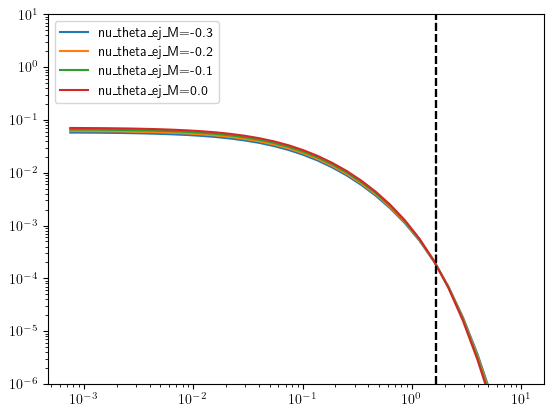

In [7]:
plt.figure()
for jth, nu_theta_ej_M in enumerate(nu_theta_ej_M_all):
    Prof_test = Prof_test_all[nu_theta_ej_M]
    plt.loglog(Prof_test.r_array, Prof_test.Pe_mat_physical[:,0,24], label=f'nu_theta_ej_M={nu_theta_ej_M}')
    plt.axvline(Prof_test.r200c_mat[0,24], color='k', linestyle='--')
    # plt.ylim(1e-10, 1e-5)
    plt.ylim(1e-6, 1e1)

plt.legend()




In [59]:
np.log10(M_chunk)


array([15.09457594, 15.12687789])

In [36]:
ymap_data = {}
for jth, nu_theta_ej_M in enumerate(nu_theta_ej_M_all):
    map_ymap_all = np.zeros(12*nside**2)
    # for indz in indz_all:              
    for indz in [indz_all]:              
        sdir = '/projects/bdne/spandey3/temp/'
        zcen = zval_all[indz]
        save_map_fname = f'{sdir}/allmaps_sim_B12_nside{nside}_z{zcen:.3f}_nu_theta{nu_theta_ej_M}_Mminhigh_nosmooth.pkl'
        with open(save_map_fname, 'rb') as f:
            data = pk.load(f)
        map_ymap_all  += data['map_ymap']
    ymap_data[nu_theta_ej_M] = map_ymap_all




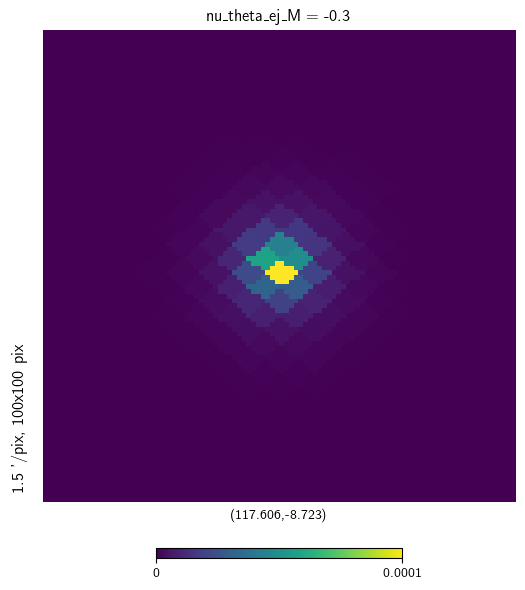

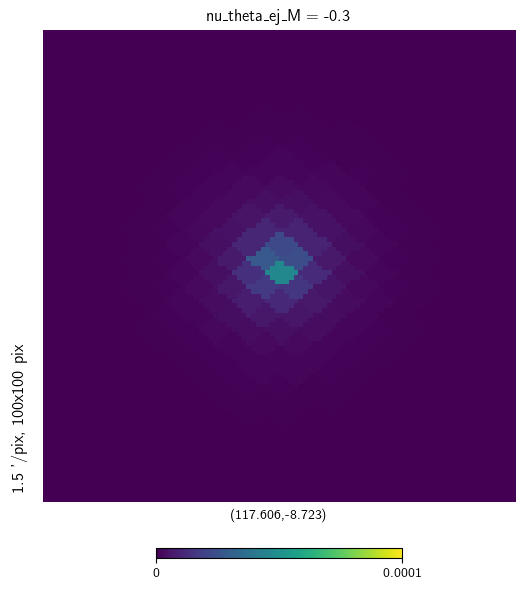

In [39]:
map0 =hp.gnomview(ymap_data[0.0], rot=(ra_chunk[0],dec_chunk[0]), xsize=100, ysize=100, title='nu_theta_ej_M = -0.3', min=0, max=1e-4, return_projected_map=True)
mapm03 =hp.gnomview(ymap_data[-0.3], rot=(ra_chunk[0],dec_chunk[0]), xsize=100, ysize=100, title='nu_theta_ej_M = -0.3', min=0, max=1e-4, return_projected_map=True)


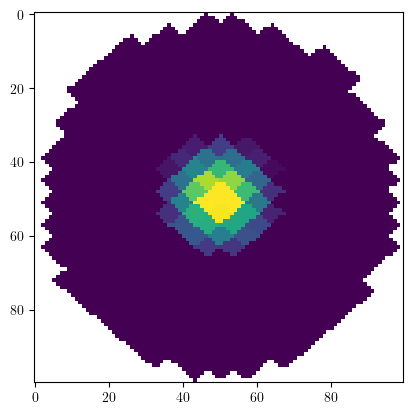

In [49]:
# map0/mapm03
# map0.data/mapm03.data
plt.figure()
plt.imshow(map0.data/mapm03.data, vmin=1.0, vmax=2.0)




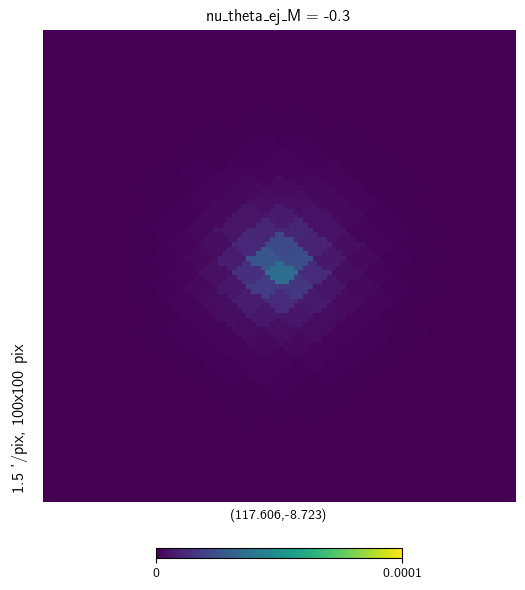

In [34]:
hp.gnomview(ymap_data[-0.3], rot=(ra_chunk[0],dec_chunk[0]), xsize=100, ysize=100, title='nu_theta_ej_M = -0.3', min=0, max=1e-4)



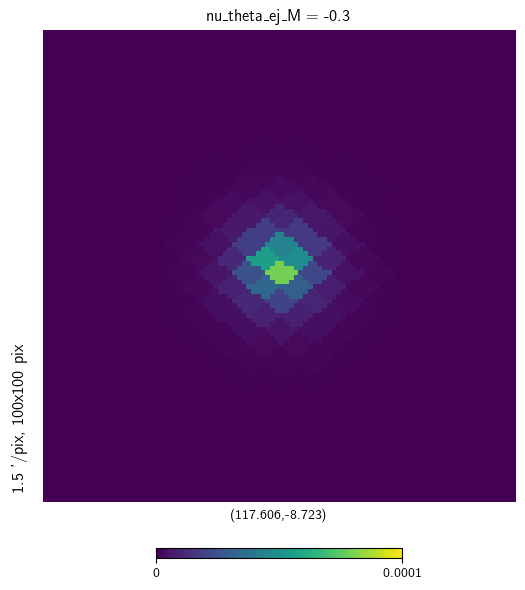

In [33]:
hp.gnomview(ymap_data[0.0], rot=(ra_chunk[0],dec_chunk[0]), xsize=100, ysize=100, title='nu_theta_ej_M = -0.3', min=0, max=1e-4)



In [ ]:
# np.log10(M_chunk[0])



np.float64(15.09457594039316)

Text(0, 0.5, '$\\ell(\\ell+1)C_\\ell/2\\pi$')

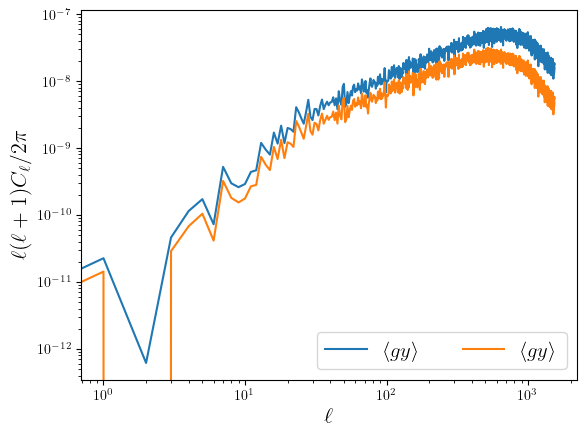

In [ ]:
plt.figure()
plt.plot(ell, ell*(ell+1)*Cl_gy2/(2.*np.pi), label=r'$\langle g y \rangle$')
plt.plot(ell, ell*(ell+1)*Cl_gy4/(2.*np.pi), label=r'$\langle g y \rangle$')
plt.legend(ncol=2, fontsize=15, loc='lower right')
# plt.ylim()
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$\ell(\ell+1)C_\ell/2\pi$', fontsize=16)






In [9]:
gal_ra_all = mock_gals_all[0][:,0]
gal_dec_all = mock_gals_all[0][:,1]
map_gal = np.zeros(12 * nside**2, dtype=np.float32)
pix_gal = hp.ang2pix(nside, gal_ra_all, gal_dec_all, lonlat=True)
np.add.at(map_gal, pix_gal, 1.)
delta_gal = (map_gal)/np.mean(map_gal)
delta_gal = hp.smoothing(delta_gal, sigma=mock_map.sigma_val)


In [13]:
Cl_gy = hp.anafast(delta_gal, map_ymap, lmax=3*nside-1)
Cl_gk = hp.anafast(delta_gal, map_kappa/np.mean(map_kappa), lmax=3*nside-1)
Cl_gtau = hp.anafast(delta_gal, map_tau, lmax=3*nside-1)
Cl_gksz2 = hp.anafast(delta_gal, map_ksz**2, lmax=3*nside-1)
ell = np.arange(len(Cl_gy))




Text(0, 0.5, '$\\ell(\\ell+1)C_\\ell/2\\pi$')

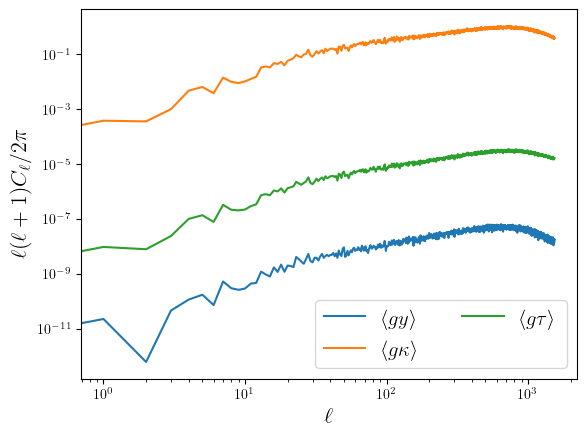

In [22]:
plt.figure()
plt.plot(ell, ell*(ell+1)*Cl_gy/(2.*np.pi), label=r'$\langle g y \rangle$')
plt.plot(ell, ell*(ell+1)*Cl_gk/(2.*np.pi), label=r'$\langle g \kappa \rangle$')
plt.plot(ell, ell*(ell+1)*Cl_gtau/(2.*np.pi), label=r'$\langle g \tau \rangle$')
# plt.plot(ell, ell*(ell+1)*Cl_gksz2/(2.*np.pi), label=r'$\langle g \textrm{kSZ}^2 \rangle$')

plt.legend(ncol=2, fontsize=15, loc='lower right')
# plt.ylim()
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$\ell(\ell+1)C_\ell/2\pi$', fontsize=16)


